In [1]:
%load_ext autoreload
%autoreload 2

In [5]:
import pandas as pd
import torch
from torch.utils.data import DataLoader, Dataset
import numpy as np
import matplotlib.pyplot as plt
from constants import CALCEDatasetConstants, MODEL_OUTPUT_PATH, NASADatasetConstants
from preprocessing_functions import generate_sliding_window_data
from models import TCN_GRU_DNN_Model, BiLSTM_Attention, abc_algorithm, BiGRUModel, CNN_DBLSTM_Model, CNN_ASTLSTM
from models.train import train_model
from models.evaluate import evaluate_model, plot_predictions
from models.save_load import save_model, load_model

In [6]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [7]:
class CustomDataset(Dataset):
    def __init__(self, x, y):
        self.x = x
        self.y = y

    def __len__(self):
        return self.y.shape[0]

    def __getitem__(self, idx):
        return self.x[idx, :], self.y[idx]

# CALCE Dataset

## Loading the Data

In [8]:
PROCESSED_BATTERY_PATHS = [CALCEDatasetConstants.BATTERY_PROCESSED_PATH.value / (battery_name+'.csv') for battery_name in CALCEDatasetConstants.BATTERY_NAMES.value]
PROCESSED_BATTERY_PATHS

[WindowsPath('C:/Users/shubham mate/Desktop/Programming/Python/Battery RUL Project/data/CALCE/Preprocessed/CS2_35.csv'),
 WindowsPath('C:/Users/shubham mate/Desktop/Programming/Python/Battery RUL Project/data/CALCE/Preprocessed/CS2_36.csv'),
 WindowsPath('C:/Users/shubham mate/Desktop/Programming/Python/Battery RUL Project/data/CALCE/Preprocessed/CS2_37.csv'),
 WindowsPath('C:/Users/shubham mate/Desktop/Programming/Python/Battery RUL Project/data/CALCE/Preprocessed/CS2_38.csv')]

In [9]:
dfs = {CALCEDatasetConstants.BATTERY_NUMBERS.value[i]: \
       pd.read_csv(PROCESSED_BATTERY_PATHS[i]).drop(['Unnamed: 0'], axis=1) for i in range(len(CALCEDatasetConstants.BATTERY_NUMBERS.value))}
dfs

{35:      Cycle_Index  Discharge_Capacity(Ah)
 0              1                1.123221
 1              2                1.111035
 2              3                1.106058
 3              4                1.102627
 4              5                1.098143
 ..           ...                     ...
 757          758                0.332357
 758          759                0.328566
 759          760                0.325232
 760          761                0.322707
 761          762                0.319955
 
 [762 rows x 2 columns],
 36:      Cycle_Index  Discharge_Capacity(Ah)
 0              1                1.134613
 1              2                1.124949
 2              3                1.121679
 3              4                1.119217
 4              5                1.115648
 ..           ...                     ...
 768          769                0.173019
 769          770                0.169924
 770          771                0.168700
 771          772                0.168793

# Visualizing the data along with train test split

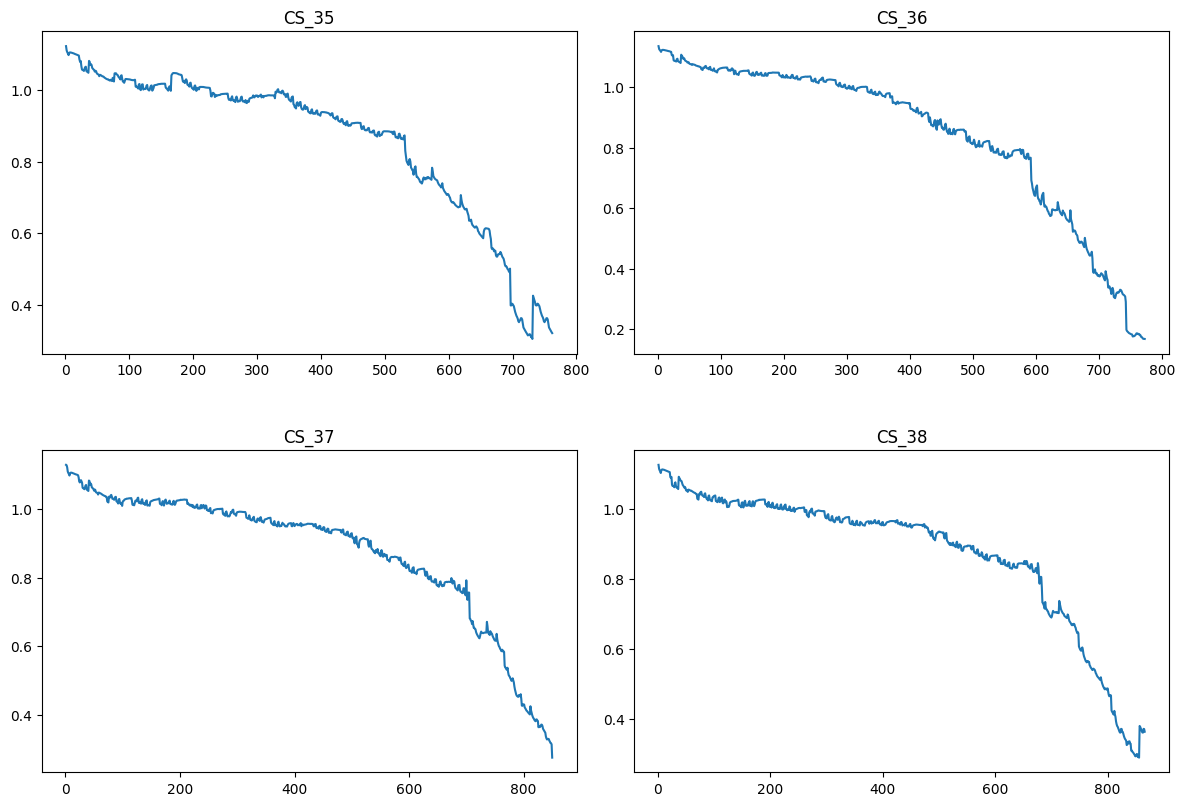

In [10]:
fig, ax = plt.subplots(nrows=int(len(dfs)/2), ncols=2, figsize=(12, 8))
fig.tight_layout()
plt.subplots_adjust(hspace=0.3)

for i, (battery_number, df) in enumerate(dfs.items()):
    ax[int(i/2), i%2].plot(df['Cycle_Index'], df['Discharge_Capacity(Ah)'])
    ax[int(i/2), i%2].set_title(f'CS_{battery_number}')

plt.show()

In [11]:
TRAINING_BATTERIES = CALCEDatasetConstants.BATTERY_NUMBERS.value[:3]
TEST_BATTERY = CALCEDatasetConstants.BATTERY_NUMBERS.value[3]

In [12]:
x, y = generate_sliding_window_data(dfs[TRAINING_BATTERIES[0]]['Discharge_Capacity(Ah)'])
x.shape, y.shape

((752, 10), (752,))

In [13]:
x.shape, y.shape

((752, 10), (752,))

In [14]:
trainX = []
trainY = []

for battery in TRAINING_BATTERIES:
    x, y = generate_sliding_window_data(dfs[battery]['Discharge_Capacity(Ah)'])
    trainX.extend(x)
    trainY.extend(y)

trainX, trainY = np.array(trainX), np.array(trainY)
trainX.shape, trainY.shape

((2355, 10), (2355,))

In [15]:
testX, testY = generate_sliding_window_data(dfs[TEST_BATTERY]['Discharge_Capacity(Ah)'])
testX, testY = np.array(testX), np.array(testY)
testX.shape, testY.shape

((856, 10), (856,))

In [16]:
train_dataset = CustomDataset(trainX, trainY)
train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)

In [17]:
test_dataset = CustomDataset(testX, testY)
test_dataloader = DataLoader(test_dataset, batch_size=32, shuffle=True)

In [19]:
MAX = 1.1
MIN = 0.0
DIFF = MAX - MIN

## TCN-GRU-DNN Model

In [20]:
model_1 = TCN_GRU_DNN_Model().to(device)
optimizer = torch.optim.Adam(model_1.parameters())
criterion = torch.nn.MSELoss()
EPOCHS = 25

train_model(
    model=model_1,
    train_dataloader=train_dataloader,
    optimizer=optimizer,
    criterion=criterion,
    device=device,
    min_val=MIN,
    diff_val=DIFF,
    epochs=EPOCHS,
    unsqueeze_dim=1,
    log_interval=1
)

C:\Users\shubham mate\Desktop\Programming\Python\Battery RUL Project\venv\Lib\site-packages\torch\nn\utils\weight_norm.py:143: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


Epoch 1/25, Loss: 0.1783
Epoch 2/25, Loss: 0.0356
Epoch 3/25, Loss: 0.0239
Epoch 4/25, Loss: 0.0019
Epoch 5/25, Loss: 0.0011
Epoch 6/25, Loss: 0.0010
Epoch 7/25, Loss: 0.0007
Epoch 8/25, Loss: 0.0006
Epoch 9/25, Loss: 0.0005
Epoch 10/25, Loss: 0.0005
Epoch 11/25, Loss: 0.0004
Epoch 12/25, Loss: 0.0004
Epoch 13/25, Loss: 0.0003
Epoch 14/25, Loss: 0.0003
Epoch 15/25, Loss: 0.0003
Epoch 16/25, Loss: 0.0002
Epoch 17/25, Loss: 0.0002
Epoch 18/25, Loss: 0.0002
Epoch 19/25, Loss: 0.0002
Epoch 20/25, Loss: 0.0002
Epoch 21/25, Loss: 0.0002
Epoch 22/25, Loss: 0.0002
Epoch 23/25, Loss: 0.0002
Epoch 24/25, Loss: 0.0002
Epoch 25/25, Loss: 0.0002


In [21]:
metrics = evaluate_model(model_1, test_dataloader, device, MIN, DIFF, 1)
print(f'RMSE: {metrics['RMSE']}\nMAE: {metrics['MAE']}')

RMSE: 0.015554876821658778
MAE: 0.012518720126876208


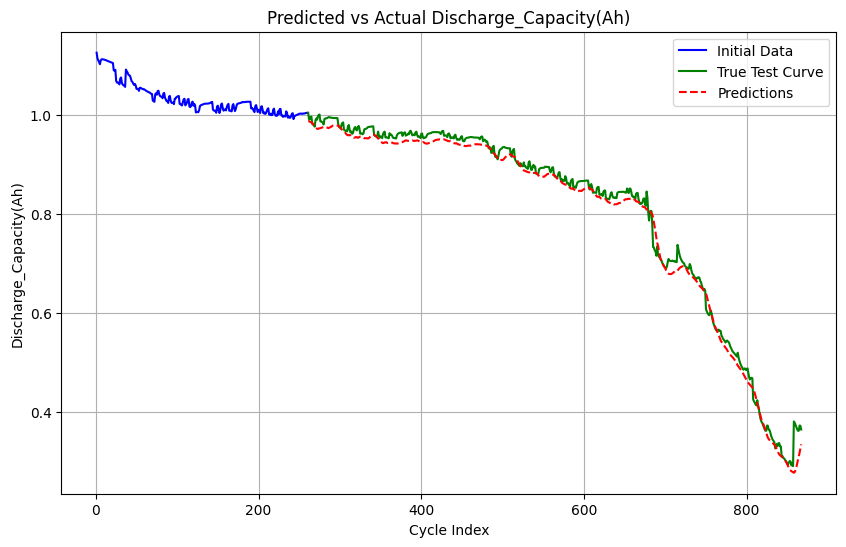

In [23]:
plot_predictions(model_1, dfs, TEST_BATTERY, generate_sliding_window_data, MIN, DIFF, device, 'Discharge_Capacity(Ah)', 1, 30)

In [50]:
save_model(model_1, MODEL_OUTPUT_PATH / 'tcn_gru_dnn.pth')

Model's state_dict saved to C:\Users\shubham mate\Desktop\Programming\Python\Battery RUL Project\saved models\tcn_gru_dnn.pth


## BiLSTM Attention Model

In [27]:
model_2 = BiLSTM_Attention(128).to(device)
optimizer = torch.optim.Adam(model_2.parameters(), lr=1e-3)
criterion = torch.nn.MSELoss()
EPOCHS = 25

train_model(
    model=model_2,
    train_dataloader=train_dataloader,
    optimizer=optimizer,
    criterion=criterion,
    device=device,
    min_val=MIN,
    diff_val=DIFF,
    epochs=EPOCHS,
    unsqueeze_dim=-1,
    log_interval=1
)

Epoch 1/25, Loss: 0.08538466359715204
Epoch 2/25, Loss: 0.006842955294445887
Epoch 3/25, Loss: 0.00040448869618263123
Epoch 4/25, Loss: 0.0006900823889835108
Epoch 5/25, Loss: 0.0002644923019574521
Epoch 6/25, Loss: 0.0002738564793174659
Epoch 7/25, Loss: 0.00026172815769559993
Epoch 8/25, Loss: 0.000237634333569912
Epoch 9/25, Loss: 0.0005777149305956571
Epoch 10/25, Loss: 0.0005616832959522317
Epoch 11/25, Loss: 0.0003817623591866986
Epoch 12/25, Loss: 0.0004454080582847284
Epoch 13/25, Loss: 0.0005127360640767005
Epoch 14/25, Loss: 0.00032190558817387065
Epoch 15/25, Loss: 0.00025542721335581074
Epoch 16/25, Loss: 0.0003213207994515353
Epoch 17/25, Loss: 0.0004921991957589116
Epoch 18/25, Loss: 0.00025613459149246556
Epoch 19/25, Loss: 0.00040265302910434865
Epoch 20/25, Loss: 0.0004884641818805265
Epoch 21/25, Loss: 0.0002897764602125421
Epoch 22/25, Loss: 0.0002008972697276968
Epoch 23/25, Loss: 0.0002966010025694551
Epoch 24/25, Loss: 0.0006283369238607938
Epoch 25/25, Loss: 0.00

In [28]:
metrics = evaluate_model(model_2, test_dataloader, device, MIN, DIFF, -1)
print(f'RMSE: {metrics['RMSE']}\nMAE: {metrics['MAE']}')

RMSE: 0.015000563033319418
MAE: 0.011119087479103392


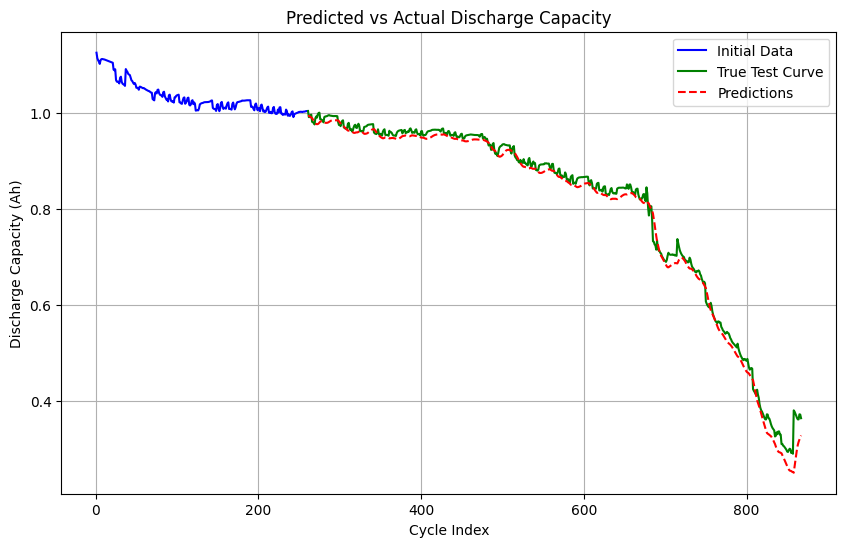

In [29]:
plot_predictions(model_2, dfs, TEST_BATTERY, generate_sliding_window_data, MIN, DIFF, device, 'Discharge_Capacity(Ah)', -1, 30)

In [51]:
save_model(model_2, MODEL_OUTPUT_PATH / 'attn_bilstm.pth')

Model's state_dict saved to C:\Users\shubham mate\Desktop\Programming\Python\Battery RUL Project\saved models\attn_bilstm.pth


## ABC (Artificial Bee Colony) BiGRU Model

In [34]:
bounds = np.array([
    [16, 128],    # Hidden size
    [1e-4, 1e-2], # Learning rate
    [0.1, 0.5]    # Dropout
])

# Run the ABC algorithm with the provided dataloaders
best_params, best_mse = abc_algorithm(bounds, train_dataloader, test_dataloader, device, n_solutions=10, max_iters=20)
print("Best Parameters:", best_params)
print("Best MSE:", best_mse)

Iteration 1/20, Best Fitness (MSE): 0.00016625280814305707
Iteration 2/20, Best Fitness (MSE): 0.00016625280814305707
Iteration 3/20, Best Fitness (MSE): 0.00016625280814305707
Iteration 4/20, Best Fitness (MSE): 0.00016625280814305707
Iteration 5/20, Best Fitness (MSE): 0.00016625280814305707
Iteration 6/20, Best Fitness (MSE): 0.00016625280814305707
Iteration 7/20, Best Fitness (MSE): 0.00016625280814305707
Iteration 8/20, Best Fitness (MSE): 0.00016625280814305707
Iteration 9/20, Best Fitness (MSE): 0.00016625280814305707
Iteration 10/20, Best Fitness (MSE): 0.00016625280814305707
Iteration 11/20, Best Fitness (MSE): 0.00015669109038922384
Iteration 12/20, Best Fitness (MSE): 0.00015669109038922384
Iteration 13/20, Best Fitness (MSE): 0.00015669109038922384
Iteration 14/20, Best Fitness (MSE): 0.00015669109038922384
Iteration 15/20, Best Fitness (MSE): 0.00015669109038922384
Iteration 16/20, Best Fitness (MSE): 0.00014784330064517067
Iteration 17/20, Best Fitness (MSE): 0.0001478433

In [37]:
model_3 = BiGRUModel(input_size=10, hidden_size=int(round(best_params[0])), dropout=best_params[2]).to(device)
optimizer = torch.optim.Adam(model_3.parameters(), lr=1e-3)
criterion = torch.nn.MSELoss()
EPOCHS = 50

train_model(
    model=model_3,
    train_dataloader=train_dataloader,
    optimizer=optimizer,
    criterion=criterion,
    device=device,
    min_val=MIN,
    diff_val=DIFF,
    epochs=EPOCHS,
    unsqueeze_dim=1,
    log_interval=1
)

Epoch 1/50, Loss: 0.06780898477882147
Epoch 2/50, Loss: 0.010346625818292031
Epoch 3/50, Loss: 0.008581176582673515
Epoch 4/50, Loss: 0.0068837099305882644
Epoch 5/50, Loss: 0.005617923653885923
Epoch 6/50, Loss: 0.005053212855174835
Epoch 7/50, Loss: 0.004771576388864903
Epoch 8/50, Loss: 0.0044737845907818425
Epoch 9/50, Loss: 0.004332308761297247
Epoch 10/50, Loss: 0.004119530505802785
Epoch 11/50, Loss: 0.004165286692236927
Epoch 12/50, Loss: 0.003933225418566852
Epoch 13/50, Loss: 0.003908275791783692
Epoch 14/50, Loss: 0.003680563528669646
Epoch 15/50, Loss: 0.0038006785781928214
Epoch 16/50, Loss: 0.003606408944579999
Epoch 17/50, Loss: 0.003523702546010247
Epoch 18/50, Loss: 0.0037520976762312488
Epoch 19/50, Loss: 0.0033545809612307393
Epoch 20/50, Loss: 0.0031731815747539135
Epoch 21/50, Loss: 0.0031363534870104412
Epoch 22/50, Loss: 0.002952610472896816
Epoch 23/50, Loss: 0.002978630579466856
Epoch 24/50, Loss: 0.003179272570697641
Epoch 25/50, Loss: 0.0029587713447777
Epoch

In [38]:
metrics = evaluate_model(model_3, test_dataloader, device, MIN, DIFF, 1)
print(f'RMSE: {metrics['RMSE']}\nMAE: {metrics['MAE']}')

RMSE: 0.009830800628651262
MAE: 0.006964301394524975


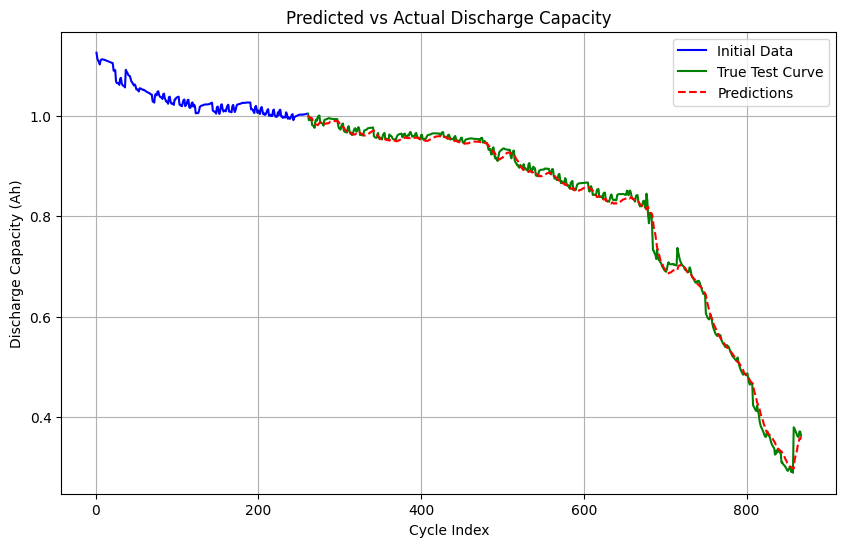

In [39]:
plot_predictions(model_3, dfs, TEST_BATTERY, generate_sliding_window_data, MIN, DIFF, device, 'Discharge_Capacity(Ah)', 1, 30)

In [52]:
save_model(model_3, MODEL_OUTPUT_PATH / 'abc_bigru.pth')

Model's state_dict saved to C:\Users\shubham mate\Desktop\Programming\Python\Battery RUL Project\saved models\abc_bigru.pth


## CNN - DBLSTM Model

In [42]:
model_4 = CNN_DBLSTM_Model([24, 48, 72], 128, 4).to(device)
optimizer = torch.optim.Adam(model_4.parameters())
criterion = torch.nn.MSELoss()
EPOCHS = 10


train_model(
    model=model_4,
    train_dataloader=train_dataloader,
    optimizer=optimizer,
    criterion=criterion,
    device=device,
    min_val=MIN,
    diff_val=DIFF,
    epochs=EPOCHS,
    unsqueeze_dim=1,
    log_interval=1
)

C:\Users\shubham mate\Desktop\Programming\Python\Battery RUL Project\venv\Lib\site-packages\torch\nn\modules\conv.py:370: UserWarning: Using padding='same' with even kernel lengths and odd dilation may require a zero-padded copy of the input be created (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\native\Convolution.cpp:1037.)
  return F.conv1d(


Epoch 1/10, Loss: 0.1462204654770274
Epoch 2/10, Loss: 0.002646517292895304
Epoch 3/10, Loss: 0.0012300311303791917
Epoch 4/10, Loss: 0.0009315880365524994
Epoch 5/10, Loss: 0.0006750462530731425
Epoch 6/10, Loss: 0.0005612208656325616
Epoch 7/10, Loss: 0.0005151846124479906
Epoch 8/10, Loss: 0.0004570759799232316
Epoch 9/10, Loss: 0.000729359995946996
Epoch 10/10, Loss: 0.0006697021156936456


In [43]:
metrics = evaluate_model(model_4, test_dataloader, device, MIN, DIFF, 1)
print(f'RMSE: {metrics['RMSE']}\nMAE: {metrics['MAE']}')

RMSE: 0.012457769072490365
MAE: 0.010380441096620025


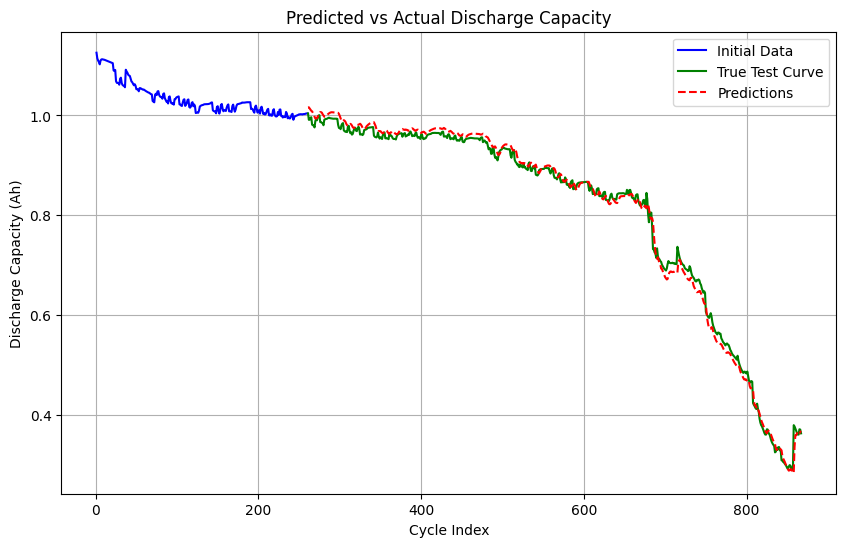

In [44]:
plot_predictions(model_4, dfs, TEST_BATTERY, generate_sliding_window_data, MIN, DIFF, device, 'Discharge_Capacity(Ah)', 1, 30)

In [53]:
save_model(model_4, MODEL_OUTPUT_PATH / 'cnn_dblstm.pth')

Model's state_dict saved to C:\Users\shubham mate\Desktop\Programming\Python\Battery RUL Project\saved models\cnn_dblstm.pth


## CNN - ASTLSTM

In [45]:
model_5 = CNN_ASTLSTM(64, 128).to(device)
optimizer = torch.optim.Adam(model_5.parameters())
criterion = torch.nn.MSELoss()
EPOCHS = 10


train_model(
    model=model_5,
    train_dataloader=train_dataloader,
    optimizer=optimizer,
    criterion=criterion,
    device=device,
    min_val=MIN,
    diff_val=DIFF,
    epochs=EPOCHS,
    unsqueeze_dim=1,
    log_interval=1
)

Epoch 1/10, Loss: 0.07523793349596294
Epoch 2/10, Loss: 0.007996429041275012
Epoch 3/10, Loss: 0.00018305705998500343
Epoch 4/10, Loss: 0.00014084913748996082
Epoch 5/10, Loss: 0.00012758668251351351
Epoch 6/10, Loss: 0.000129319074010316
Epoch 7/10, Loss: 0.00015258024944381072
Epoch 8/10, Loss: 0.00014861169059971675
Epoch 9/10, Loss: 0.00014704668776814928
Epoch 10/10, Loss: 0.00010488565985232944


In [46]:
metrics = evaluate_model(model_5, test_dataloader, device, MIN, DIFF, 1)
print(f'RMSE: {metrics['RMSE']}\nMAE: {metrics['MAE']}')

RMSE: 0.008967455156062032
MAE: 0.006156276511115448


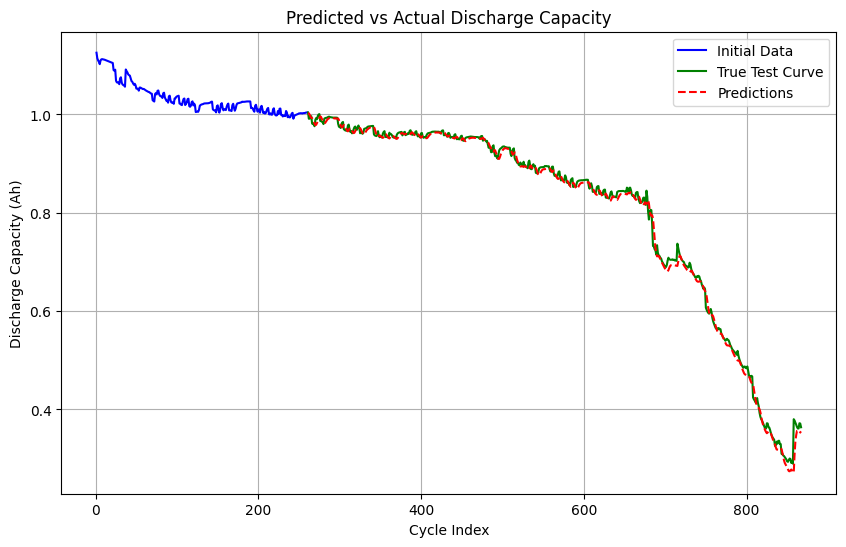

In [47]:
plot_predictions(model_5, dfs, TEST_BATTERY, generate_sliding_window_data, MIN, DIFF, device, 'Discharge_Capacity(Ah)', 1, 30)

In [54]:
save_model(model_5, MODEL_OUTPUT_PATH / 'cnn_astlstm.pth')

Model's state_dict saved to C:\Users\shubham mate\Desktop\Programming\Python\Battery RUL Project\saved models\cnn_astlstm.pth


# NASA Dataset

In [24]:
nasa_dfs = {NASADatasetConstants.BATTERY_NAMES.value[i]: \
       pd.read_csv(NASADatasetConstants.BATTERY_FILEPATHS.value[i]) for i in range(len(NASADatasetConstants.BATTERY_NAMES.value))}
nasa_dfs

{'B0005':      cycle  amb_temp              date_time  voltage_battery  current_battery  \
 0        1        24  02 Apr 2008, 15:25:41         3.277170        -0.006528   
 1        3        24  02 Apr 2008, 19:43:48         3.300245        -0.000448   
 2        5        24  03 Apr 2008, 00:01:06         3.327451         0.001026   
 3        7        24  03 Apr 2008, 04:16:37         3.314182        -0.002234   
 4        9        24  03 Apr 2008, 08:33:25         3.305497         0.000009   
 ..     ...       ...                    ...              ...              ...   
 163    599        24  26 May 2008, 10:44:38         3.615561        -0.002548   
 164    603        24  26 May 2008, 15:30:43         3.621191        -0.002460   
 165    607        24  26 May 2008, 20:21:04         3.619185         0.000478   
 166    611        24  27 May 2008, 15:52:41         3.595365        -0.002342   
 167    613        24  27 May 2008, 20:45:42         3.589937        -0.000583   
 
     

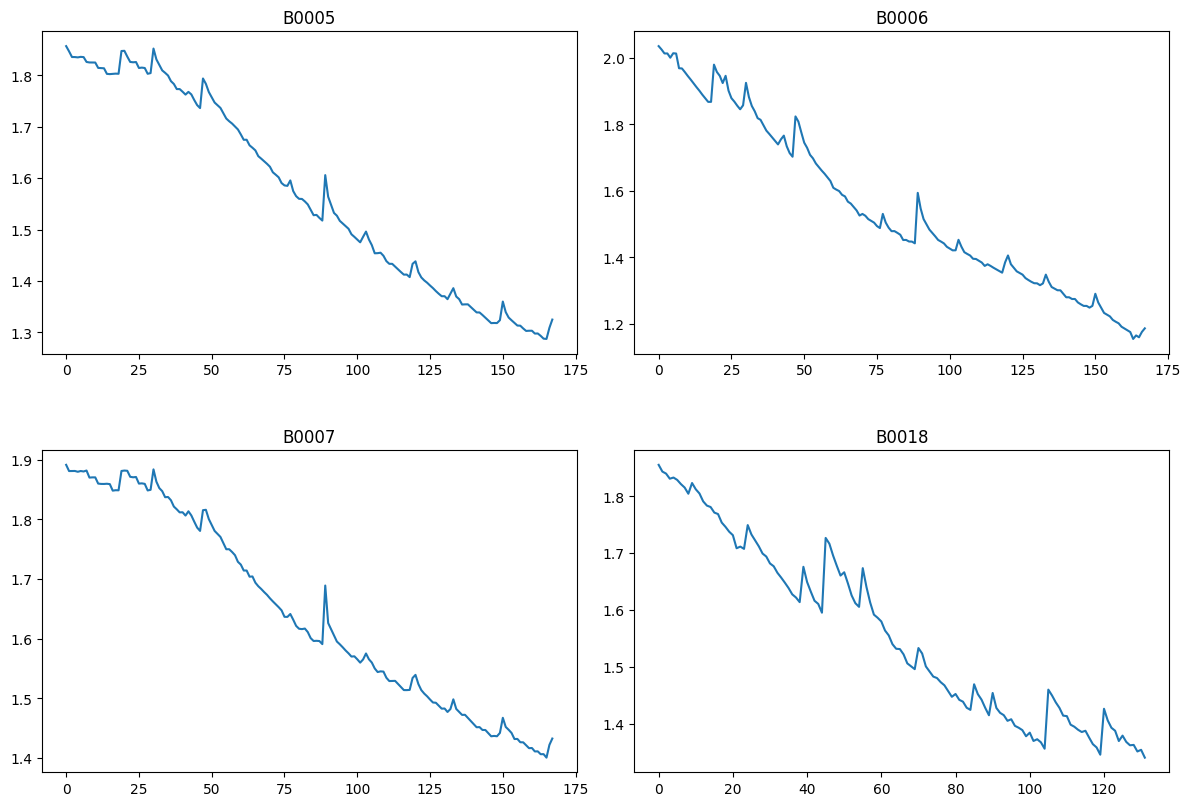

In [25]:
fig, ax = plt.subplots(nrows=int(len(nasa_dfs)/2), ncols=2, figsize=(12, 8))
fig.tight_layout()
plt.subplots_adjust(hspace=0.3)

for i, (battery_number, df) in enumerate(nasa_dfs.items()):
    ax[int(i/2), i%2].plot(df.index, df['capacity'])
    ax[int(i/2), i%2].set_title(f'{battery_number}')

plt.show()

In [26]:
NASA_TRAINING_BATTERIES = NASADatasetConstants.BATTERY_NAMES.value[:3]
NASA_TEST_BATTERY = NASADatasetConstants.BATTERY_NAMES.value[3]

In [27]:
NASA_trainX = []
NASA_trainY = []

for battery in NASA_TRAINING_BATTERIES:
    x, y = generate_sliding_window_data(nasa_dfs[battery]['capacity'])
    NASA_trainX.extend(x)
    NASA_trainY.extend(y)

NASA_trainX, NASA_trainY = np.array(NASA_trainX), np.array(NASA_trainY)
NASA_trainX.shape, NASA_trainY.shape

((474, 10), (474,))

In [29]:
NASA_testX, NASA_testY = generate_sliding_window_data(nasa_dfs[NASA_TEST_BATTERY]['capacity'])
NASA_testX, NASA_testY = np.array(NASA_testX), np.array(NASA_testY)
NASA_testX.shape, NASA_testY.shape

((122, 10), (122,))

In [30]:
NASA_train_dataset = CustomDataset(NASA_trainX, NASA_trainY)
NASA_train_dataloader = DataLoader(NASA_train_dataset, batch_size=32, shuffle=True)

NASA_test_dataset = CustomDataset(NASA_testX, NASA_testY)
NASA_test_dataloader = DataLoader(NASA_test_dataset, batch_size=32, shuffle=True)

In [31]:
MIN = 0.0
MAX = 2.0
DIFF = MAX - MIN

## TCN-GRU-DNN Model

In [32]:
model_1 = TCN_GRU_DNN_Model().to(device)
optimizer = torch.optim.Adam(model_1.parameters())
criterion = torch.nn.MSELoss()
EPOCHS = 100


train_model(
    model=model_1,
    train_dataloader=NASA_train_dataloader,
    optimizer=optimizer,
    criterion=criterion,
    device=device,
    min_val=MIN,
    diff_val=DIFF,
    epochs=EPOCHS,
    unsqueeze_dim=1,
    log_interval=1
)

C:\Users\shubham mate\Desktop\Programming\Python\Battery RUL Project\venv\Lib\site-packages\torch\nn\utils\weight_norm.py:143: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


Epoch 1/100, Loss: 1.1511388699213663
Epoch 2/100, Loss: 1.0646303256352743
Epoch 3/100, Loss: 0.9662016948064168
Epoch 4/100, Loss: 0.8319296956062316
Epoch 5/100, Loss: 0.6465481360753377
Epoch 6/100, Loss: 0.3778949568669001
Epoch 7/100, Loss: 0.10524191657702128
Epoch 8/100, Loss: 0.013125229130188624
Epoch 9/100, Loss: 0.011512240891655286
Epoch 10/100, Loss: 0.009672379742066065
Epoch 11/100, Loss: 0.00958259217441082
Epoch 12/100, Loss: 0.00940870369474093
Epoch 13/100, Loss: 0.00941477504869302
Epoch 14/100, Loss: 0.009418125947316487
Epoch 15/100, Loss: 0.009416512120515108
Epoch 16/100, Loss: 0.009333479714890321
Epoch 17/100, Loss: 0.009436258673667907
Epoch 18/100, Loss: 0.009375831733147303
Epoch 19/100, Loss: 0.009293036255985498
Epoch 20/100, Loss: 0.00938457939773798
Epoch 21/100, Loss: 0.009326789031426112
Epoch 22/100, Loss: 0.009315726223091285
Epoch 23/100, Loss: 0.009260928320387999
Epoch 24/100, Loss: 0.00932723389317592
Epoch 25/100, Loss: 0.00930306628967325
Epo

In [33]:
metrics = evaluate_model(model_1, NASA_test_dataloader, device, MIN, DIFF, 1)
print(f'RMSE: {metrics['RMSE']}\nMAE: {metrics['MAE']}')

RMSE: 0.01788324987728353
MAE: 0.012134869079120824


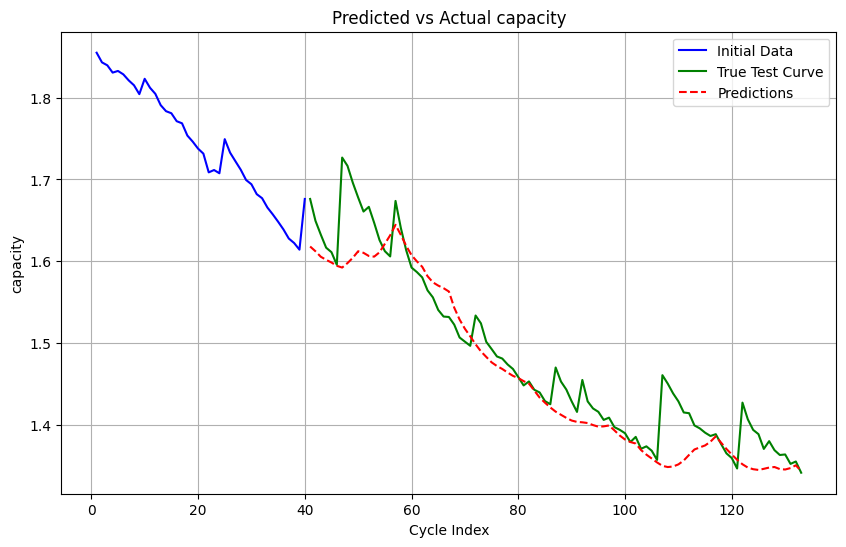

In [35]:
plot_predictions(model_1, nasa_dfs, NASA_TEST_BATTERY, generate_sliding_window_data, MIN, DIFF, device, 'capacity', 1, 30)

## BiLSTM Attention Model

In [38]:
model_2 = BiLSTM_Attention(128).to(device)
optimizer = torch.optim.Adam(model_2.parameters(), lr=1e-3)
criterion = torch.nn.MSELoss()
EPOCHS = 25

train_model(
    model=model_2,
    train_dataloader=NASA_train_dataloader,
    optimizer=optimizer,
    criterion=criterion,
    device=device,
    min_val=MIN,
    diff_val=DIFF,
    epochs=EPOCHS,
    unsqueeze_dim=-1,
    log_interval=1
)

Epoch 1/25, Loss: 0.3675580163796743
Epoch 2/25, Loss: 0.04209705200046301
Epoch 3/25, Loss: 0.016889818385243414
Epoch 4/25, Loss: 0.010290890901039044
Epoch 5/25, Loss: 0.010230858996510505
Epoch 6/25, Loss: 0.010074154163400332
Epoch 7/25, Loss: 0.009878289171804984
Epoch 8/25, Loss: 0.010039303513864676
Epoch 9/25, Loss: 0.009953799626479546
Epoch 10/25, Loss: 0.010074492668112119
Epoch 11/25, Loss: 0.00994311502824227
Epoch 12/25, Loss: 0.010060386670132478
Epoch 13/25, Loss: 0.010330396487067144
Epoch 14/25, Loss: 0.010068181219200294
Epoch 15/25, Loss: 0.009948919092615445
Epoch 16/25, Loss: 0.009813303065796693
Epoch 17/25, Loss: 0.009770639551182589
Epoch 18/25, Loss: 0.01013735355809331
Epoch 19/25, Loss: 0.009466217023630936
Epoch 20/25, Loss: 0.0066125447939460475
Epoch 21/25, Loss: 0.0014428088014634946
Epoch 22/25, Loss: 0.000606023141881451
Epoch 23/25, Loss: 0.0004242827999405563
Epoch 24/25, Loss: 0.0004300356415721277
Epoch 25/25, Loss: 0.0002567382374157508


In [39]:
metrics = evaluate_model(model_2, NASA_test_dataloader, device, MIN, DIFF, -1)
print(f'RMSE: {metrics['RMSE']}\nMAE: {metrics['MAE']}')

RMSE: 0.017323608988214542
MAE: 0.014731170212636228


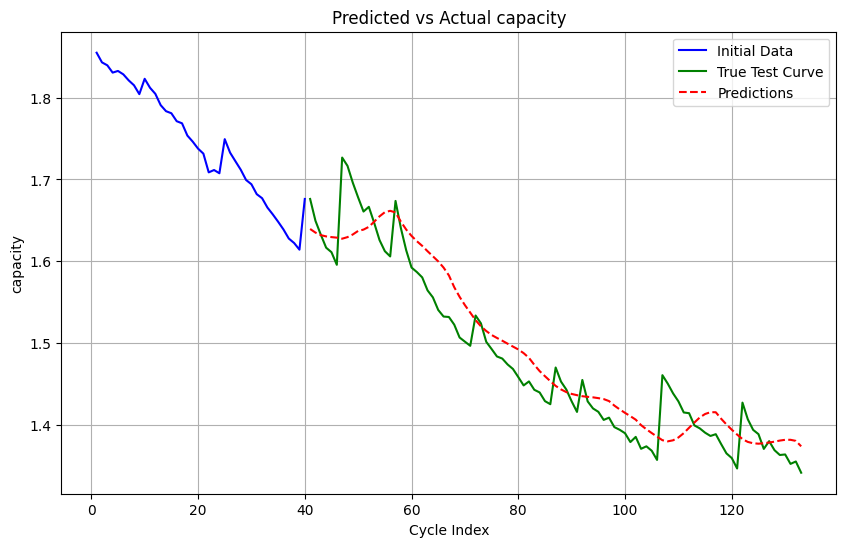

In [41]:
plot_predictions(model_2, nasa_dfs, NASA_TEST_BATTERY, generate_sliding_window_data, MIN, DIFF, device, 'capacity', -1, 30)

## ABC (Artificial Bee Colony) BiGRU Model

In [42]:
bounds = np.array([
    [16, 128],    # Hidden size
    [1e-4, 1e-2], # Learning rate
    [0.1, 0.5]    # Dropout
])

# Run the ABC algorithm with the provided dataloaders
best_params, best_mse = abc_algorithm(bounds, NASA_train_dataloader, NASA_test_dataloader, device, n_solutions=10, max_iters=20)
print("Best Parameters:", best_params)
print("Best MSE:", best_mse)

Iteration 1/20, Best Fitness (MSE): 0.002369544963585213
Iteration 2/20, Best Fitness (MSE): 0.002369544963585213
Iteration 3/20, Best Fitness (MSE): 0.002208225429058075
Iteration 4/20, Best Fitness (MSE): 0.002208225429058075
Iteration 5/20, Best Fitness (MSE): 0.002208225429058075
Iteration 6/20, Best Fitness (MSE): 0.002208225429058075
Iteration 7/20, Best Fitness (MSE): 0.002208225429058075
Iteration 8/20, Best Fitness (MSE): 0.0015527622599620372
Iteration 9/20, Best Fitness (MSE): 0.0015527622599620372
Iteration 10/20, Best Fitness (MSE): 0.0015527622599620372
Iteration 11/20, Best Fitness (MSE): 0.0015527622599620372
Iteration 12/20, Best Fitness (MSE): 0.0015527622599620372
Iteration 13/20, Best Fitness (MSE): 0.0015527622599620372
Iteration 14/20, Best Fitness (MSE): 0.0015527622599620372
Iteration 15/20, Best Fitness (MSE): 0.0015527622599620372
Iteration 16/20, Best Fitness (MSE): 0.0015527622599620372
Iteration 17/20, Best Fitness (MSE): 0.0015527622599620372
Iteration 18/

In [45]:
model_3 = BiGRUModel(input_size=10, hidden_size=int(round(best_params[0])), dropout=best_params[2]).to(device)
optimizer = torch.optim.Adam(model_3.parameters(), lr=1e-3)
criterion = torch.nn.MSELoss()
EPOCHS = 100

train_model(
    model=model_3,
    train_dataloader=NASA_train_dataloader,
    optimizer=optimizer,
    criterion=criterion,
    device=device,
    min_val=MIN,
    diff_val=DIFF,
    epochs=EPOCHS,
    unsqueeze_dim=1,
    log_interval=1
)

Epoch 1/100, Loss: 0.2683735338350137
Epoch 2/100, Loss: 0.014630188575635354
Epoch 3/100, Loss: 0.009668228588998318
Epoch 4/100, Loss: 0.006199022227277359
Epoch 5/100, Loss: 0.004576439488058289
Epoch 6/100, Loss: 0.004443444808324178
Epoch 7/100, Loss: 0.004019785315419236
Epoch 8/100, Loss: 0.004118945123627782
Epoch 9/100, Loss: 0.004313708562403917
Epoch 10/100, Loss: 0.0044911933286736405
Epoch 11/100, Loss: 0.004342312303682168
Epoch 12/100, Loss: 0.004231823468580842
Epoch 13/100, Loss: 0.003833104701091846
Epoch 14/100, Loss: 0.003833580451707045
Epoch 15/100, Loss: 0.0036124931881204247
Epoch 16/100, Loss: 0.003534959629178047
Epoch 17/100, Loss: 0.0038269785232841968
Epoch 18/100, Loss: 0.003658801456913352
Epoch 19/100, Loss: 0.003255648111614088
Epoch 20/100, Loss: 0.0031469502951949834
Epoch 21/100, Loss: 0.0031298524389664333
Epoch 22/100, Loss: 0.0034215877220655482
Epoch 23/100, Loss: 0.00347334126320978
Epoch 24/100, Loss: 0.003283616427021722
Epoch 25/100, Loss: 0.

In [46]:
metrics = evaluate_model(model_3, NASA_test_dataloader, device, MIN, DIFF, 1)
print(f'RMSE: {metrics['RMSE']}\nMAE: {metrics['MAE']}')

RMSE: 0.014082027298347427
MAE: 0.010431465555409917


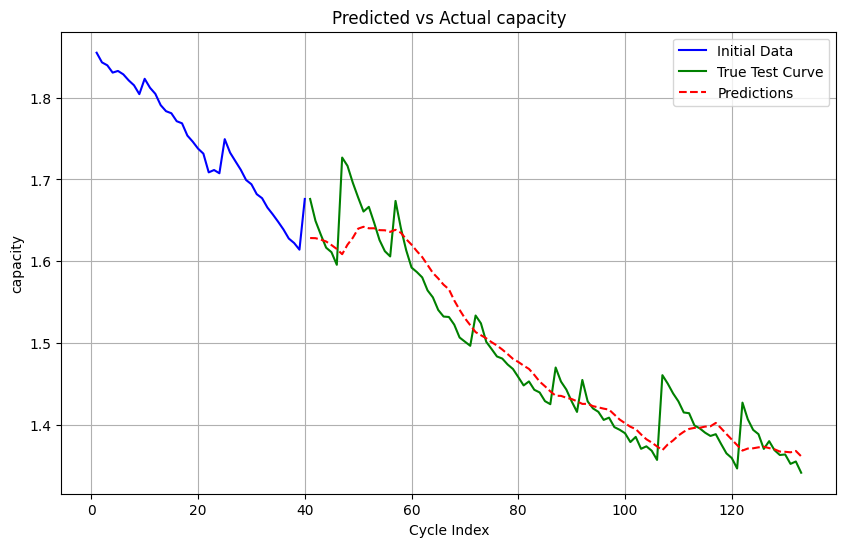

In [48]:
plot_predictions(model_3, nasa_dfs, NASA_TEST_BATTERY, generate_sliding_window_data, MIN, DIFF, device, 'capacity', 1, 30)

## CNN - DBLSTM Model

In [49]:
model_4 = CNN_DBLSTM_Model([24, 48, 72], 128, 4).to(device)
optimizer = torch.optim.Adam(model_4.parameters())
criterion = torch.nn.MSELoss()
EPOCHS = 50


train_model(
    model=model_4,
    train_dataloader=NASA_train_dataloader,
    optimizer=optimizer,
    criterion=criterion,
    device=device,
    min_val=MIN,
    diff_val=DIFF,
    epochs=EPOCHS,
    unsqueeze_dim=1,
    log_interval=1
)

C:\Users\shubham mate\Desktop\Programming\Python\Battery RUL Project\venv\Lib\site-packages\torch\nn\modules\conv.py:370: UserWarning: Using padding='same' with even kernel lengths and odd dilation may require a zero-padded copy of the input be created (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\native\Convolution.cpp:1037.)
  return F.conv1d(


Epoch 1/50, Loss: 0.49558582256237665
Epoch 2/50, Loss: 0.028345561462144057
Epoch 3/50, Loss: 0.01465982428441445
Epoch 4/50, Loss: 0.010554756596684456
Epoch 5/50, Loss: 0.009793115252008041
Epoch 6/50, Loss: 0.009203810710459948
Epoch 7/50, Loss: 0.008190284948796034
Epoch 8/50, Loss: 0.005231297994032502
Epoch 9/50, Loss: 0.001416999464466547
Epoch 10/50, Loss: 0.001426118400801594
Epoch 11/50, Loss: 0.0012295423861360178
Epoch 12/50, Loss: 0.0006696227685703585
Epoch 13/50, Loss: 0.0006447958895781388
Epoch 14/50, Loss: 0.00035893619885124886
Epoch 15/50, Loss: 0.001105875294888392
Epoch 16/50, Loss: 0.000976926990551874
Epoch 17/50, Loss: 0.0007219156313415927
Epoch 18/50, Loss: 0.0006380529647382597
Epoch 19/50, Loss: 0.0006450507207773626
Epoch 20/50, Loss: 0.0010407087936376532
Epoch 21/50, Loss: 0.0008670923654184056
Epoch 22/50, Loss: 0.0012512265840390077
Epoch 23/50, Loss: 0.0007161457469919696
Epoch 24/50, Loss: 0.00032243391130274784
Epoch 25/50, Loss: 0.0004459585470613

In [50]:
metrics = evaluate_model(model_4, NASA_test_dataloader, device, MIN, DIFF, 1)
print(f'RMSE: {metrics['RMSE']}\nMAE: {metrics['MAE']}')

RMSE: 0.015729829170452805
MAE: 0.01165133616963371


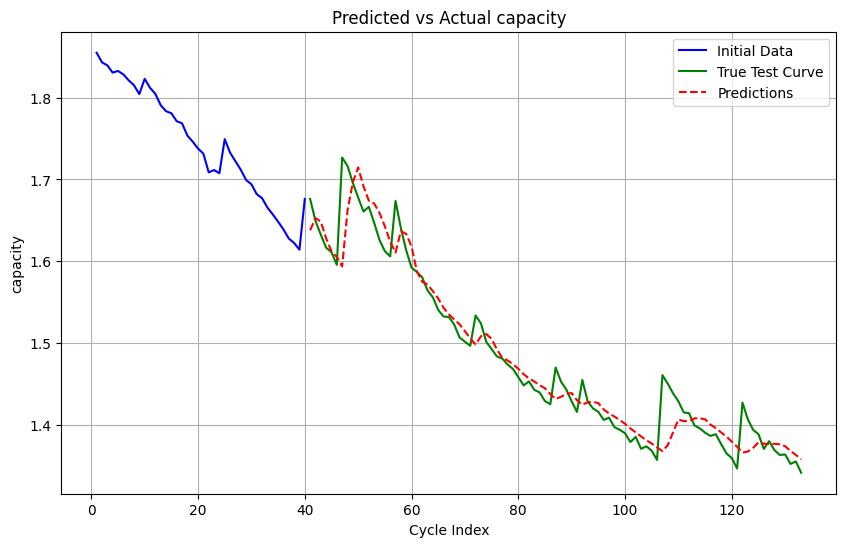

In [52]:
plot_predictions(model_4, nasa_dfs, NASA_TEST_BATTERY, generate_sliding_window_data, MIN, DIFF, device, 'capacity', 1, 30)

## CNN - ASTLSTM

In [53]:
model_5 = CNN_ASTLSTM(64, 128).to(device)
optimizer = torch.optim.Adam(model_5.parameters())
criterion = torch.nn.MSELoss()
EPOCHS = 50


train_model(
    model=model_5,
    train_dataloader=NASA_train_dataloader,
    optimizer=optimizer,
    criterion=criterion,
    device=device,
    min_val=MIN,
    diff_val=DIFF,
    epochs=EPOCHS,
    unsqueeze_dim=1,
    log_interval=1
)

Epoch 1/50, Loss: 0.23159727454185486
Epoch 2/50, Loss: 0.02886339332908392
Epoch 3/50, Loss: 0.013844231143593788
Epoch 4/50, Loss: 0.010774502779046695
Epoch 5/50, Loss: 0.009899452918519576
Epoch 6/50, Loss: 0.00969408533225457
Epoch 7/50, Loss: 0.009603084561725457
Epoch 8/50, Loss: 0.009538990414390961
Epoch 9/50, Loss: 0.00944491634145379
Epoch 10/50, Loss: 0.009118798188865185
Epoch 11/50, Loss: 0.008467321346203486
Epoch 12/50, Loss: 0.0067412959566960735
Epoch 13/50, Loss: 0.0035490552506720024
Epoch 14/50, Loss: 0.0013862139079719783
Epoch 15/50, Loss: 0.0007435555414607128
Epoch 16/50, Loss: 0.0005246652426042904
Epoch 17/50, Loss: 0.0003785439868806861
Epoch 18/50, Loss: 0.0002691569156013429
Epoch 19/50, Loss: 0.00020357842877274379
Epoch 20/50, Loss: 0.00015493583220328825
Epoch 21/50, Loss: 0.00014982347493059934
Epoch 22/50, Loss: 0.00015179716162189532
Epoch 23/50, Loss: 0.0002148462381834785
Epoch 24/50, Loss: 0.00020456930651562287
Epoch 25/50, Loss: 0.00023248405923

In [54]:
metrics = evaluate_model(model_5, NASA_test_dataloader, device, MIN, DIFF, 1)
print(f'RMSE: {metrics['RMSE']}\nMAE: {metrics['MAE']}')

RMSE: 0.013665291219406368
MAE: 0.007487830079969813


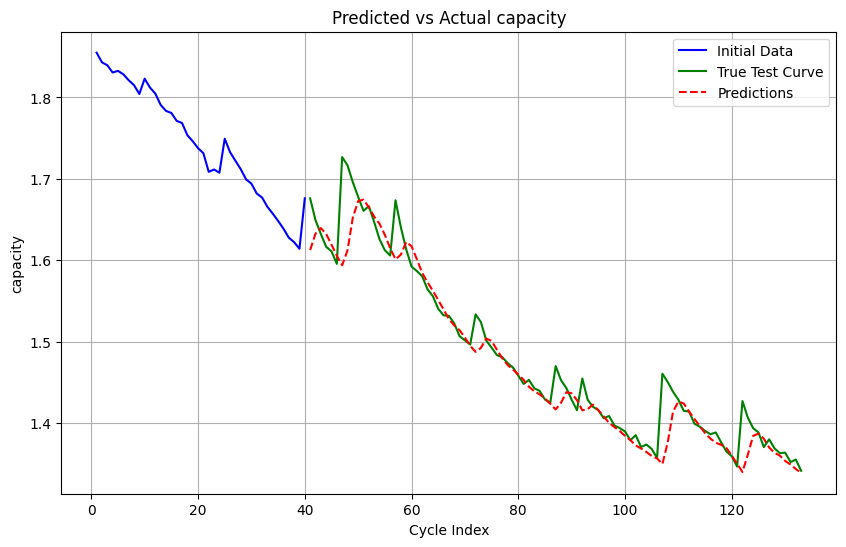

In [55]:
plot_predictions(model_5, nasa_dfs, NASA_TEST_BATTERY, generate_sliding_window_data, MIN, DIFF, device, 'capacity', 1, 30)